# The centred Fourier convention

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/mrutils/blob/main/examples/fourier.ipynb)

`fftc`, `ifftc`, `resize_centered` and `remove_readout_oversampling`: the
transform an MRI reconstruction means when it says "the Fourier transform",
stated once so nothing downstream re-derives the shifts.

In [1]:
try:
    import mrutils  # noqa: F401
except ImportError:
    %pip install -q "mrutils[torch]" matplotlib

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import mrutils as mru


def phantom(n=128):
    """A Shepp-Logan phantom on an n x n grid."""
    y, x = np.mgrid[-1 : 1 : n * 1j, -1 : 1 : n * 1j]
    ellipses = [
        # value, centre x, centre y, semi-axis a, semi-axis b, degrees
        (1.0, 0.0, 0.0, 0.69, 0.92, 0),
        (-0.8, 0.0, -0.0184, 0.6624, 0.874, 0),
        (-0.2, 0.22, 0.0, 0.11, 0.31, -18),
        (-0.2, -0.22, 0.0, 0.16, 0.41, 18),
        (0.1, 0.0, 0.35, 0.21, 0.25, 0),
        (0.1, 0.0, 0.1, 0.046, 0.046, 0),
        (0.1, 0.0, -0.1, 0.046, 0.046, 0),
        (0.1, -0.08, -0.605, 0.046, 0.023, 0),
        (0.1, 0.0, -0.606, 0.023, 0.023, 0),
        (0.1, 0.06, -0.605, 0.023, 0.046, 0),
    ]
    image = np.zeros((n, n))
    for value, cx, cy, a, b, degrees in ellipses:
        angle = np.deg2rad(degrees)
        xr = (x - cx) * np.cos(angle) + (y - cy) * np.sin(angle)
        yr = -(x - cx) * np.sin(angle) + (y - cy) * np.cos(angle)
        image[(xr / a) ** 2 + (yr / b) ** 2 <= 1.0] += value
    return image


image = phantom(128)
print(image.shape, image.dtype)

(128, 128) float64


## The convention

`fftc` is `ifftshift -> fft(norm="ortho") -> fftshift`. Two things follow, and
both are visible below: DC lands in the middle of the array rather than in its
corner, and the transform is orthonormal, so the round trip returns the object
to machine precision and Parseval holds without a scale factor anywhere.

round trip 4.43e-16, energy ratio 1.000000


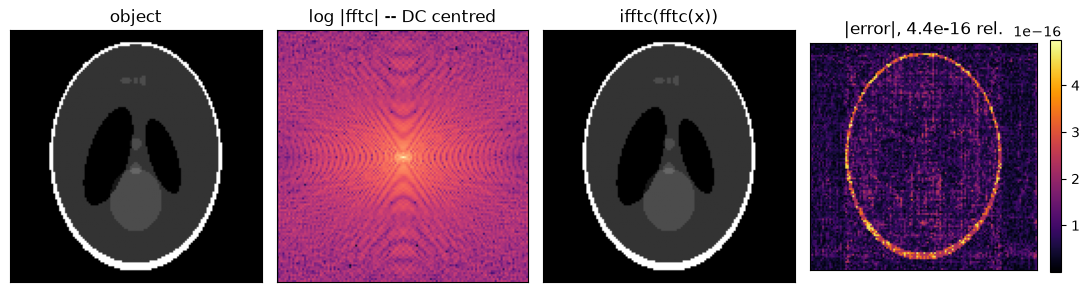

In [3]:
kspace = mru.fftc(image)
recovered = mru.ifftc(kspace)

round_trip = np.linalg.norm(recovered - image) / np.linalg.norm(image)
energy = np.linalg.norm(kspace) / np.linalg.norm(image)
print(f"round trip {round_trip:.2e}, energy ratio {energy:.6f}")

fig, axes = plt.subplots(1, 4, figsize=(11, 3))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("object")
axes[1].imshow(np.log10(np.abs(kspace) + 1e-6), cmap="magma")
axes[1].set_title("log |fftc| -- DC centred")
axes[2].imshow(np.abs(recovered), cmap="gray")
axes[2].set_title("ifftc(fftc(x))")
error = axes[3].imshow(np.abs(recovered - image), cmap="inferno")
axes[3].set_title(f"|error|, {round_trip:.1e} rel.")
fig.colorbar(error, ax=axes[3], fraction=0.046)
for axis in axes:
    axis.set_xticks([])
    axis.set_yticks([])
fig.tight_layout()

In [4]:
# Written only when the notebook runs inside a clone, and it is what the
# README shows -- so the figure in the README is always this cell's output.
figures = Path("figures")
if figures.is_dir():
    fig.savefig(figures / "fourier.png", dpi=110, bbox_inches="tight")

## Resizing about the centre

`resize_centered` crops or zero-pads the trailing axes about the same centre
`fftshift` uses, so cropping k-space is a resolution change and padding it is
an interpolation. Neither moves the object, which is the property to look for
in the profiles: the edges of the phantom stay where they were.

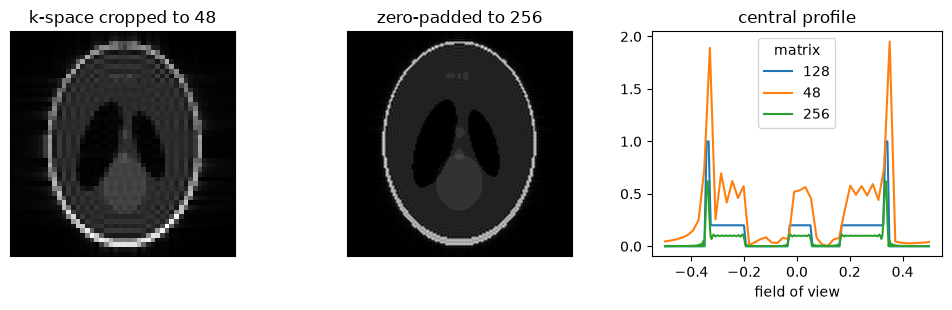

In [5]:
coarse = mru.ifftc(mru.resize_centered(kspace, (48, 48)))
interpolated = mru.ifftc(mru.resize_centered(kspace, (256, 256)))

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
axes[0].imshow(np.abs(coarse), cmap="gray")
axes[0].set_title("k-space cropped to 48")
axes[1].imshow(np.abs(interpolated), cmap="gray")
axes[1].set_title("zero-padded to 256")
for axis in axes[:2]:
    axis.set_xticks([])
    axis.set_yticks([])

for label, data in (("128", image), ("48", np.abs(coarse)), ("256", np.abs(interpolated))):
    row = data[data.shape[0] // 2]
    axes[2].plot(np.linspace(-0.5, 0.5, row.size), row, label=label)
axes[2].set_title("central profile")
axes[2].set_xlabel("field of view")
axes[2].legend(title="matrix")
fig.tight_layout()

## Readout oversampling

A scanner digitises more samples along the readout than the prescribed matrix
asks for, so the anti-aliasing filter has room to roll off. Those samples are
field of view, not resolution, so they come off in the image domain:
`remove_readout_oversampling` is an image-domain crop, not a k-space one.

The object below occupies the middle half of the digitised field of view --
which is what twofold oversampling leaves room for -- so removing it is
lossless. Compare that with discarding the outer half of k-space, which is a
resolution loss and blurs the edges.

image-domain crop reproduces the object to 8.36e-16


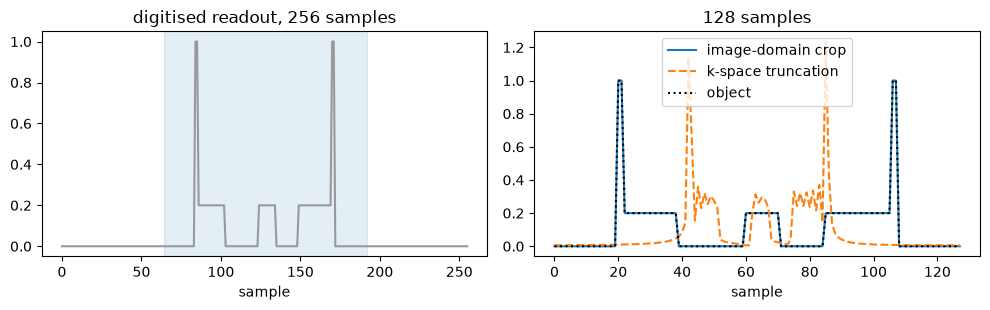

In [6]:
digitised = np.zeros((1, 256), dtype=complex)
digitised[0, 64:192] = phantom(128)[64]
readout = mru.fftc(digitised, axes=-1)

cropped = mru.remove_readout_oversampling(readout, 128)
naive = mru.resize_centered(readout, (128,))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].plot(np.abs(mru.ifftc(readout, axes=-1)[0]), color="0.6")
axes[0].axvspan(64, 192, color="tab:blue", alpha=0.12)
axes[0].set_title("digitised readout, 256 samples")
axes[0].set_xlabel("sample")

axes[1].plot(np.abs(mru.ifftc(cropped, axes=-1)[0]), label="image-domain crop")
axes[1].plot(np.abs(mru.ifftc(naive, axes=-1)[0]), "--", label="k-space truncation")
axes[1].plot(np.abs(digitised[0, 64:192]), ":", color="k", label="object")
axes[1].set_title("128 samples")
axes[1].set_xlabel("sample")
axes[1].legend()
fig.tight_layout()

exact = np.linalg.norm(mru.ifftc(cropped, axes=-1)[0] - digitised[0, 64:192])
print(f"image-domain crop reproduces the object to {exact:.2e}")